In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

import math
import numpy as np

In [17]:
def count_stats(qc):
    qc.measure_all()

    simulator = AerSimulator()
    result = simulator.run(qc, shots=1000).result()
    counts = result.get_counts()
 
    return counts

### №1. Реализовать вентиль CCCX

Чтобы было попроще, распишем логику такого вентиля через таблицу:

|q0|q1|q2|q3|=>|
|-|-|-|-|-|
|0|0|0|0|0|
|0|0|0|1|1|
|0|0|1|0|0|
|0|0|1|1|1|
|0|1|0|0|0|
|0|1|0|1|1|
|0|1|1|0|0|
|0|1|1|1|1|
|1|0|0|0|0|
|1|0|0|1|1|
|1|0|1|0|0|
|1|0|1|1|1|
|1|1|0|0|0|
|1|1|0|1|1|
|1|1|1|0|**1**|
|1|1|1|1|**0**|

Без вспомогательного фотона здесь не обойтись...

> Логическое "И" (AND) можно выразить через "ИЛИ" (OR) и "НЕ" (NOT) с помощью Законов ДеМоргана: A И B равно НЕ (НЕ A ИЛИ НЕ B).

> A XOR B можно выразить как (A AND NOT B) OR (NOT A AND B) или (A OR B) AND NOT (A AND B).

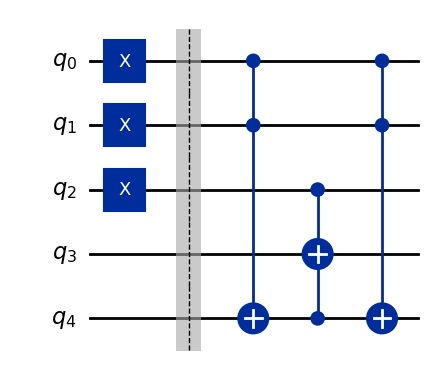

In [18]:
qc = QuantumCircuit(5) # 4 + 1 вспом

qc.x([0, 1, 2])
# qc.x(3)
qc.barrier()

# qc.ccx(0, 1, 3) # 0 и 1 == 1 -> Будет 1
# qc.z(4)         # Если было 1, будет -1
# qc.ccz(1, 2, 4) # Если было -1, будет 1
# qc.cx(4, 3)     # Если вконце получилось 1, применяем CNOT

qc.ccx(0, 1, 4)
qc.ccx(2, 4, 3)
qc.ccx(0, 1, 4)

qc.draw('mpl')

In [19]:
count_stats(qc)

{'01111': 1000}

### №2. Реализовать вентиль CCCZ

Реализация будет практически аналогичная

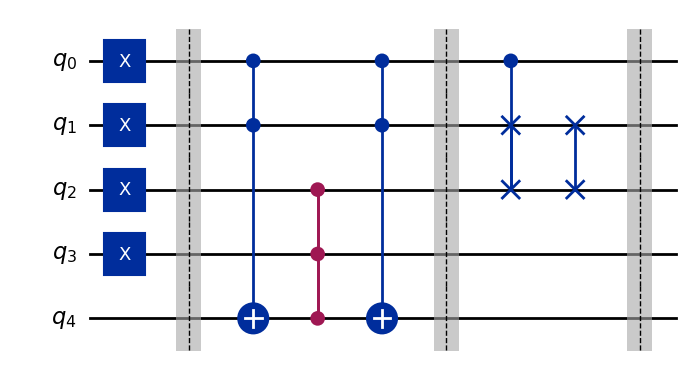

In [ ]:
qc = QuantumCircuit(5)

qc.x([0, 1, 2])
qc.x(3)
qc.barrier()

qc.ccx(0, 1, 4)
qc.ccz(2, 4, 3)
qc.ccx(0, 1, 4)

qc.barrier()
# Вентиль Фредкина -- здесь не нужен, но на зачёте может быть полезен!
qc.cswap(0, 1, 2)
# Он же, но без управляющего кубита (просто меняет 2 кубита местами)
qc.swap(1, 2)
qc.barrier()

qc.draw('mpl')

In [21]:
count_stats(qc)

{'01111': 1000}

### №3. Реализовать вентиль CCCCX

Нужно два вспомогательных кубита

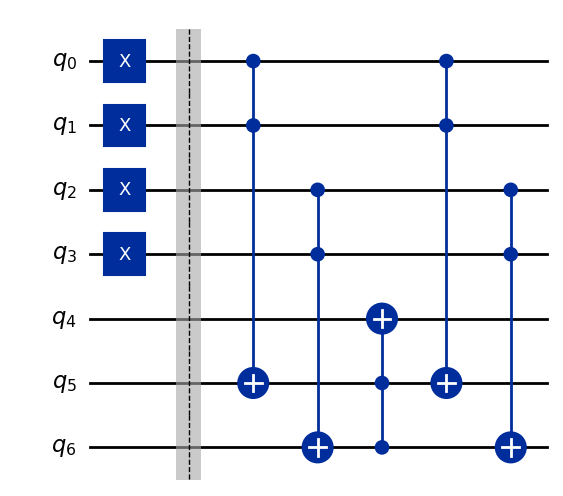

In [22]:
qc = QuantumCircuit(7) # 5 + 2 вспом

qc.x([0, 1, 2, 3])
# qc.x(4)
qc.barrier()

qc.ccx(0, 1, 5)
qc.ccx(2, 3, 6)
qc.ccx(6, 5, 4)
qc.ccx(0, 1, 5)
qc.ccx(2, 3, 6)

qc.draw('mpl')

In [23]:
count_stats(qc)

{'0011111': 1000}

# Вентили RX, RY

Вентиль для поворота на произвольный угол КАСАНЕ ТЕТО ТЕ ТЕ ТЕ ТЕ ТЕ ТЕТО на осях X и Y соответственно.

![](res/08.2.png)

**Поглазеть на анимацию поворота на шаре Лоха: https://kawaihome.link/jbooks/qcomp-short/q1gates/r.html**

Вентили позволяют делать поворот _на произвольный угол_:

$$ R_x(\theta) | \ 0 > \ = \cos(\frac{\theta}2) | \ 0 > \ - i \sin(\frac{\theta}2) | \ 1 > $$

$$ R_y(\theta) | \ 0 > \ = \cos(\frac{\theta}2) | \ 0 > \ + \sin(\frac{\theta}2) | \ 1 > $$

Таким образом:

$$a| \ 0 > = \cos(\frac{\theta}2) \implies P| \ 0 > = \cos^2(\frac{\theta}2)$$
$$a| \ 1 > = \sin(\frac{\theta}2) \implies P| \ 1 > = \sin^2(\frac{\theta}2)$$

Например:

$| \ \phi > = \sqrt{0.8} | \ 0 > + \sqrt{0.2} | \ 1 >$

$P_0 = \cos^2(\frac{\theta}2) = 0.8 = 80 \ \%$

$\theta = 2 \arccos(\sqrt(P_0)) =$ `2*acos(√(0.8))` $= 0.927$ радиан.

_(примерно аналогичный алогритм нахождения и через $P_1$)_

### №4. Посчитать углы поворота в радианах для RX и RY на основе данных процентных соотношений через (а) $P| \ 0 >$ (одинаково и для RX и для RY), (б) $P| \ 1 > $ для RX (а) $P| \ 0 >$ для RY

(первое число — % для |0>, второе — % для |1>, соответственно)

In [24]:
percent_pairs = np.array([
    [80, 20],
    [20, 80],
    [55, 45],
    [70, 30],
    [90, 10],
    [99, 1],
    [33, 66],
    [15, 85],
])

In [25]:
percent_pairs = np.array([
    [80, 20],
    [20, 80],
    [55, 45],
    [70, 30],
    [90, 10],
    [99, 1],
    [33, 66],
    [15, 85],
])

results = []

for pct_0, pct_1 in percent_pairs:
    p0 = pct_0 / 100.0
    p1 = pct_1 / 100.0

    # САМАЯ ВАЖНАЯ ЧАСТЬ -- ВЫЧИСЛЕНИЕ УГЛА ИЗ ВЕРОЯТНОСТЕЙ
    theta_p0_RX_RY = 2 * np.arccos(np.sqrt(p0))  # Для P0 в RX и RY
    theta_p1_RX = 2 * np.arcsin(np.sqrt(p1))     # Для P1 в RX
    theta_p1_RY = 2 * np.arccos(np.sqrt(1 - p1)) # Для P1 в RY
    
    results.append({
        'pct_0': pct_0, 'pct_1': pct_1,
        'p0': p0, 'p1': p1,
        'theta_p0_RX_RY': theta_p0_RX_RY,
        'theta_p1_RX': theta_p1_RX,
        'theta_p1_RY': theta_p1_RY,
    })

for i, r in enumerate(results):
    print(f"№{i}: P0 = {r['pct_0']}%, P1 = {r['pct_1']}%")
    print(f"• θ по P0      = {r['theta_p0_RX_RY']:.6f} рад = {np.degrees(r['theta_p0_RX_RY']):.3f}°")
    print(f"• θ по P1 в RX = {r['theta_p1_RX']:.6f} рад = {np.degrees(r['theta_p1_RX']):.3f}°")
    print(f"• θ по P1 в RY = {r['theta_p1_RY']:.6f} рад = {np.degrees(r['theta_p1_RY']):.3f}°")
    print()

№0: P0 = 80%, P1 = 20%
• θ по P0      = 0.927295 рад = 53.130°
• θ по P1 в RX = 0.927295 рад = 53.130°
• θ по P1 в RY = 0.927295 рад = 53.130°

№1: P0 = 20%, P1 = 80%
• θ по P0      = 2.214297 рад = 126.870°
• θ по P1 в RX = 2.214297 рад = 126.870°
• θ по P1 в RY = 2.214297 рад = 126.870°

№2: P0 = 55%, P1 = 45%
• θ по P0      = 1.470629 рад = 84.261°
• θ по P1 в RX = 1.470629 рад = 84.261°
• θ по P1 в RY = 1.470629 рад = 84.261°

№3: P0 = 70%, P1 = 30%
• θ по P0      = 1.159279 рад = 66.422°
• θ по P1 в RX = 1.159279 рад = 66.422°
• θ по P1 в RY = 1.159279 рад = 66.422°

№4: P0 = 90%, P1 = 10%
• θ по P0      = 0.643501 рад = 36.870°
• θ по P1 в RX = 0.643501 рад = 36.870°
• θ по P1 в RY = 0.643501 рад = 36.870°

№5: P0 = 99%, P1 = 1%
• θ по P0      = 0.200335 рад = 11.478°
• θ по P1 в RX = 0.200335 рад = 11.478°
• θ по P1 в RY = 0.200335 рад = 11.478°

№6: P0 = 33%, P1 = 66%
• θ по P0      = 1.917713 рад = 109.877°
• θ по P1 в RX = 1.896526 рад = 108.663°
• θ по P1 в RY = 1.896526 рад